In [78]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [79]:
import pandas as pd
import numpy as np

In [80]:
r = np.full((20, 1000),fill_value=np.nan)

In [81]:
df = pd.read_csv('ratings_long.csv')

In [82]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [83]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

### Dataset Definition:

- Dataset Length = 200
- Number Of Unique Users = 20 Users Id in [0,19]
- Number of Unique Movies = 179
- Possible Ratings in [1,5]

In [84]:
print(f"Number of distinct movies are: {df['movieId'].nunique()}")
print(f"Number of distinct users are: {df['userId'].nunique()}")
print(f"Shape of dataframe df is: {df.shape}")
print(f"Shape of r is: {r.shape}")
print(f"Possible rating values for a movie: {sorted(df['rating'].unique())}")
print(f"Users in the system by Id: {df['userId'].unique()}")

Number of distinct movies are: 179
Number of distinct users are: 20
Shape of dataframe df is: (200, 3)
Shape of r is: (20, 1000)
Possible rating values for a movie: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Users in the system by Id: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


### Checking How Many Labeled Datapoints We Have (200 points, 1 percent)

In [85]:
rows, cols = r.shape
possible_ratings = [1,2,3,4,5]

valid_datapoints = 0
for row in range(rows):
    for col in range(cols):
        if r[row][col] in possible_ratings:
            valid_datapoints += 1

print(valid_datapoints)

200


### 1.Creating the Class For Classification Model Which Includes:
- Transforming Data Into a Dict in the Format ((userId, movieId), rating),
Which Makes The Dataset Easier to Iterate(find_labeled_datas method)
- Required Helper Functions (e.g. dot product, train step, update weight, regulizers(L1, L2 and Elasticnet)
- Learning Rate
- Patience and Early Stopping Percentage
- Visualization of Training Losses

In [86]:
from dataclasses import dataclass, field
from typing import Tuple
import matplotlib.pyplot as plt

@dataclass
class Rating_Predicter:
    data: np.ndarray
    u_shape: Tuple[int, int] = (20, 4)
    v_shape: Tuple[int, int] = (4, 1000)
    lr: float = 0.01
    early_stop_percentage: float = 1.0
    patience: int = 20
    
    reg_type: str = None
    reg_lambda: float = 0.001
    l1_ratio: float = 0.5

    u: np.ndarray = field(init=False)
    v: np.ndarray = field(init=False)
    dataset: dict = field(default_factory=dict)

    def find_labeled_datas(self):
        labeled_data = []
    
        rows, cols = self.data.shape
        for i in range(rows):
            for j in range(cols):
                curr_value = self.data[i][j]
                if not np.isnan(curr_value):
                    labeled_data.append(((i, j), curr_value))
    
        self.dataset = labeled_data
    
    def __post_init__(self):
        self.u = np.random.normal(0, 0.1, self.u_shape)
        self.v = np.random.normal(0, 0.1, self.v_shape)
        self.find_labeled_datas()

    def forward(self, userId : int, movieId : int):
        return self.dot_product(userId, movieId)
    
    def dot_product(self, row: int, column: int):
        return np.dot(self.u[row, :], self.v[:, column])

    def calculate_loss(self, y_pred, y_true, row=None, col=None):
        mse_loss = 0.5 * (y_pred - y_true) ** 2
        
        if self.reg_type is None or row is None or col is None:
            return mse_loss
        
        u_vec = self.u[row, :]
        v_vec = self.v[:, col]
        
        if self.reg_type == "l2":
            reg_loss = 0.5 * self.reg_lambda * (
                np.sum(u_vec ** 2) + np.sum(v_vec ** 2)
            )
        
        elif self.reg_type == "l1":
            reg_loss = self.reg_lambda * (
                np.sum(np.abs(u_vec)) + np.sum(np.abs(v_vec))
            )
        
        elif self.reg_type == "elasticnet":
            l1_part = self.l1_ratio * (
                np.sum(np.abs(u_vec)) + np.sum(np.abs(v_vec))
            )
        
            l2_part = 0.5 * (1 - self.l1_ratio) * (
                np.sum(u_vec ** 2) + np.sum(v_vec ** 2)
            )
        
            reg_loss = self.reg_lambda * (l1_part + l2_part)
        
        else:
            raise ValueError("reg_type must be None, 'l1', 'l2' or 'elasticnet'")
        
        return mse_loss + reg_loss

    def calculate_error(self, y_pred, y_true):
        return y_pred - y_true

    def update_weights(self, error: float, row: int, col: int):
        u_old = self.u[row, :].copy()
        v_old = self.v[:, col].copy()
    
        grad_u = error * v_old
        grad_v = error * u_old
    
        if self.reg_type == "l2":
            grad_u += self.reg_lambda * u_old
            grad_v += self.reg_lambda * v_old
    
        elif self.reg_type == "l1":
            grad_u += self.reg_lambda * np.sign(u_old)
            grad_v += self.reg_lambda * np.sign(v_old)
    
        elif self.reg_type == "elasticnet":
            grad_u += self.reg_lambda * (
                self.l1_ratio * np.sign(u_old) + (1 - self.l1_ratio) * u_old
            )
    
            grad_v += self.reg_lambda * (
                self.l1_ratio * np.sign(v_old) + (1 - self.l1_ratio) * v_old
            )
    
        self.u[row, :] -= self.lr * grad_u
        self.v[:, col] -= self.lr * grad_v
    
    def train_step(self, data):
        row, column = data[0]
        y_true = data[1]

        y_pred = self.forward(row, column)

        error = self.calculate_error(y_pred, y_true)
        loss = self.calculate_loss(y_pred, y_true, row, column)

        self.update_weights(error, row, column)

        return loss

    def train(
        self,
        num_epoch: int = 10000,
        early_stop: bool = True,
        plot_train: bool = True,
        patience: int = 20,
        early_stop_start_epoch: int = 100
    ):
        losses = []
    
        best_loss = float("inf")
        epochs_without_improvement = 0
    
        for epoch in range(num_epoch):
            shuffled_dataset = self.dataset.copy()
            np.random.shuffle(shuffled_dataset)
    
            cumulative_loss = 0
    
            for data in shuffled_dataset:
                cumulative_loss += self.train_step(data=data)
    
            avg_loss = cumulative_loss / len(shuffled_dataset)
            losses.append(avg_loss)
    
            if epoch % 100 == 0:
                print(f"Epoch: {epoch} Loss: {avg_loss}")
    
            if early_stop and epoch > early_stop_start_epoch:
                improvement_threshold = best_loss * (1 - self.early_stop_percentage / 100)
    
                if avg_loss < improvement_threshold:
                    best_loss = avg_loss
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1
    
                if epochs_without_improvement >= patience:
                    print(f"Early stopped at epoch {epoch}")
                    print(f"Best loss: {best_loss}")
                    break
            else:
                if avg_loss < best_loss:
                    best_loss = avg_loss
    
        if plot_train:
            self.plot_training(losses)
    
        return losses

    def predict_sample(self, num_samples : int = 1):
        for sample in range(num_samples):
            sample = self.dataset[np.random.randint(0, len(self.dataset))]
            (row, column), y_true = sample
            y_pred = self.forward(row, column)
        
            print(f"User ID: {row}")
            print(f"Movie ID: {column}")
            print(f"True rating: {y_true}")
            print(f"Predicted rating: {y_pred}")

    def plot_training(self, losses : list):
        if losses is None or len(losses) == 0:
            print("Loss listesi boş.")
            return
    
        plt.figure(figsize=(8, 5))
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss")
        plt.grid(True)
        plt.show()
        

### Initializing The Model and Training The Model With Training Loss Graph

Epoch: 0 Loss: 5.536400292463607
Epoch: 100 Loss: 0.006925942056549741
Early stopped at epoch 178
Best loss: 0.006557794266029021


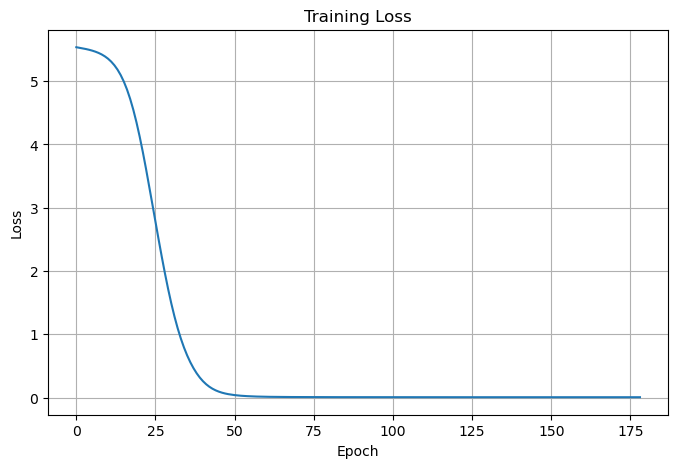

Final loss: 0.0065332153613198475


In [87]:
model = Rating_Predicter(
    data=r,
    u_shape=(r.shape[0], 4),
    v_shape=(4, r.shape[1]),
    lr=0.01,
    reg_type="elasticnet",
    reg_lambda=0.001,
    l1_ratio=0.5
)

losses = model.train(
    num_epoch=10000,
    early_stop=True,
    patience=30,
    early_stop_start_epoch=100
)

print("Final loss:", losses[len(losses)-1])

### Some Example Predictions (I know there is Data Leakage)

In [77]:
model.predict_sample(5)

User ID: 3
Movie ID: 746
True rating: 3.0
Predicted rating: 2.998823438766383
User ID: 2
Movie ID: 638
True rating: 2.0
Predicted rating: 1.9990318717545599
User ID: 17
Movie ID: 201
True rating: 4.0
Predicted rating: 3.9981376252684844
User ID: 18
Movie ID: 572
True rating: 5.0
Predicted rating: 5.000904102152638
User ID: 0
Movie ID: 764
True rating: 2.0
Predicted rating: 1.9979624153701505
